# 266. Palindrome Permutation
https://leetcode.com/problems/palindrome-permutation/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| HashMap count | O(n) | O(k) | Count chars, check odd counts |
| **Set toggle (Optimal)** | **O(n)** | **O(k)** | Toggle chars in set, check size |

## Methodology

A string can form a palindrome if at most one character has an odd frequency. We use a set: add a character if not present, remove if present. At the end, if the set size is 0 or 1, a palindrome permutation exists.

## Solutions

### C#

In [ ]:
public class Solution {
    public bool CanPermutePalindrome(string s) {
        var set = new HashSet<char>();
        foreach (char c in s) {
            if (!set.Add(c)) set.Remove(c);
        }
        return set.Count <= 1;
    }
}

### Python

In [ ]:
class Solution:
    def canPermutePalindrome(self, s: str) -> bool:
        odds = set()
        for c in s:
            if c in odds:
                odds.remove(c)
            else:
                odds.add(c)
        return len(odds) <= 1

### Go

In [ ]:
func canPermutePalindrome(s string) bool {
    set := make(map[rune]bool)
    for _, c := range s {
        if set[c] {
            delete(set, c)
        } else {
            set[c] = true
        }
    }
    return len(set) <= 1
}

### Rust

In [ ]:
use std::collections::HashSet;

impl Solution {
    pub fn can_permute_palindrome(s: String) -> bool {
        let mut set = HashSet::new();
        for c in s.chars() {
            if !set.insert(c) {
                set.remove(&c);
            }
        }
        set.len() <= 1
    }
}

## Example Scenarios

1. **Common Case**  
   **Input:** `s = "aab"`  
   Character counts: `{a:2, b:1}`. Only one character has an odd count, so a palindrome is possible. Returns `true`.

2. **Slightly Complex**  
   **Input:** `s = "carerac"`  
   Counts: `{c:2, a:2, r:2, e:1}`. One odd count ($e$). Can form "carerac" $\to$ "racecar". Returns `true`.

3. **Edge Case: Time Factor**  
   **Input:** `s` has $5000$ characters, all the same letter `"aaaa...a"`.  
   Toggle set ends with one element (odd length). $O(n)$ pass over all 5000 chars. Returns `true`.

4. **Edge Case: Space Factor**  
   **Input:** `s = "abcdefghijklmnopqrstuvwxyz"`  
   All 26 distinct characters, each appears once. Set grows to size 26 ($O(k)$ space where $k=26$). All counts odd $\Rightarrow$ returns `false`.

5. **Almost-Impossible but Plausible**  
   **Input:** `s = "a"`  
   Single character is trivially a palindrome. Set has exactly 1 element. Returns `true`.

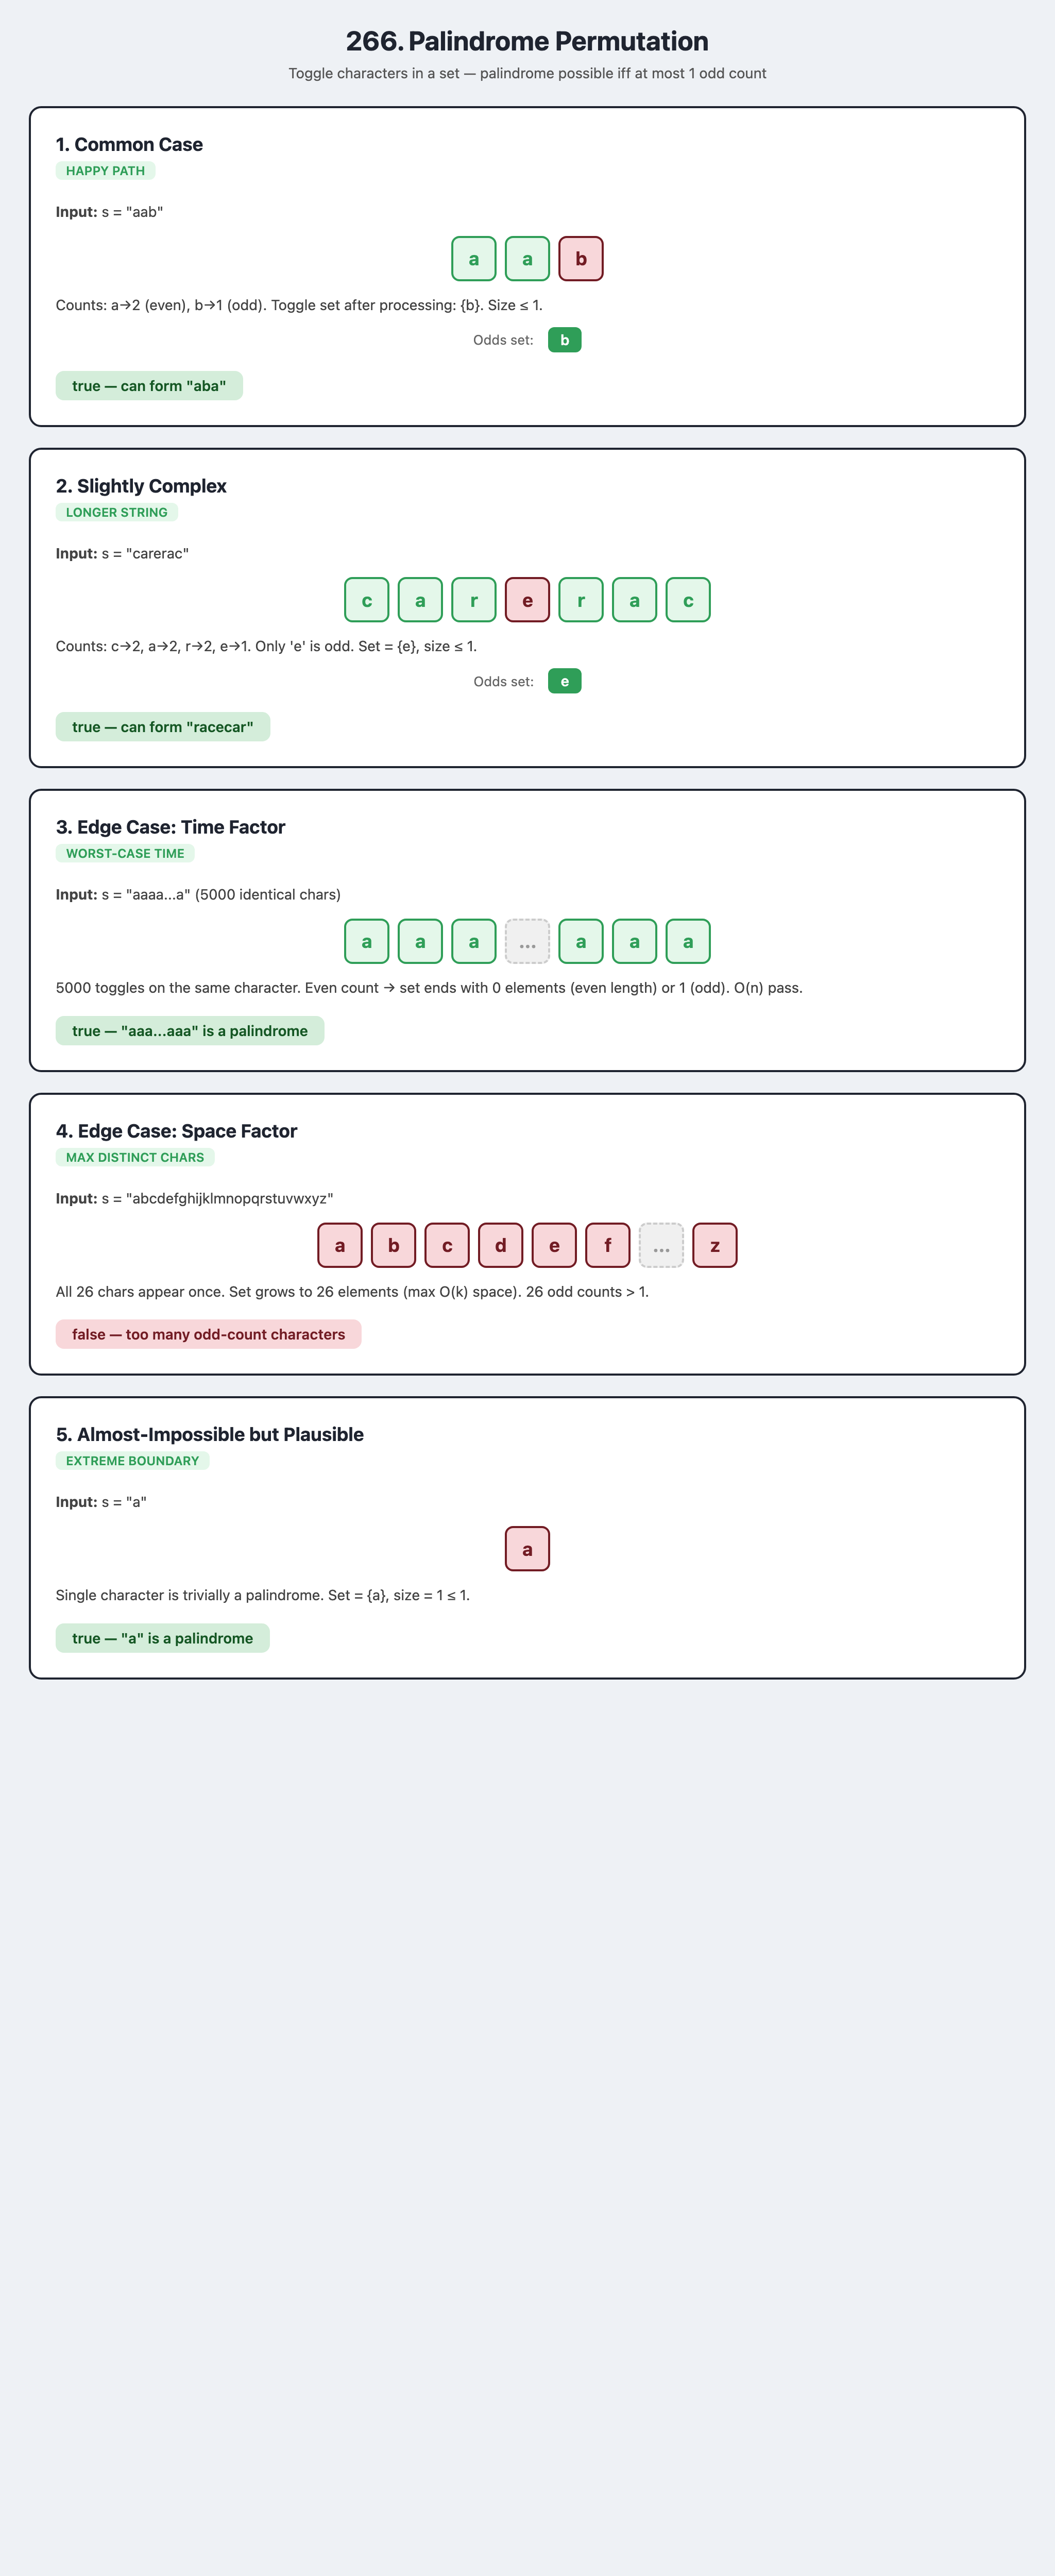